# Wine Regions

Fresh workflow for the Wine-page geometry upgrade.

Goal: start from the cleaned AOC source, inspect what is present, and compare payload-reduction strategies before writing any new app-facing GeoJSON.


## Setup

This notebook should stay light at the top. The early cells load and inspect `WineData/aoc_regions.gpkg`; heavier dissolve/export experiments are gated later.


In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", str((Path.cwd() / ".matplotlib-cache").resolve()))

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "WineData").exists() and (NOTEBOOK_DIR / "Development" / "WineData").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "Development"

DATA_DIR = NOTEBOOK_DIR / "WineData"
SOURCE_PATH = DATA_DIR / "aoc_regions.gpkg"
GENERATED_DIR = DATA_DIR / "generated"
REQUIRED_AOC_COLUMNS = {"region", "app", "colour", "geometry"}

plt.rcParams.update({"figure.dpi": 130})
print(f"Source: {SOURCE_PATH}")


Source: /Users/Ian/Documents/Study/Stage3/Programming/Github/Michelin_App_Development/Development/WineData/aoc_regions.gpkg


## Load and Verify Source

The source should already be clean. If this contract fails, stop here rather than reviving the old merge/cleanup cells.


In [2]:
aoc = gpd.read_file(SOURCE_PATH, engine="pyogrio")

missing_columns = sorted(REQUIRED_AOC_COLUMNS.difference(aoc.columns))
if missing_columns:
    raise ValueError(f"Missing required source columns: {missing_columns}")

attribute_columns = ["region", "app", "colour"]
source_contract = pd.Series({
    "file_size_mb": round(SOURCE_PATH.stat().st_size / 1024**2, 1),
    "rows": len(aoc),
    "crs": str(aoc.crs),
    "columns": ", ".join(aoc.columns),
    "geometry_types": ", ".join(sorted(aoc.geometry.geom_type.unique())),
    "regions": aoc["region"].nunique(),
    "apps": aoc["app"].nunique(),
    "null_attribute_values": int(aoc[attribute_columns].isna().sum().sum()),
    "blank_attribute_values": int(aoc[attribute_columns].astype(str).apply(lambda col: col.str.strip().eq("")).sum().sum()),
    "duplicate_app_rows": int(aoc.duplicated(subset=["app"]).sum()),
    "missing_geometries": int(aoc.geometry.isna().sum()),
    "empty_geometries": int(aoc.geometry.is_empty.sum()),
    "invalid_geometries": int((~aoc.geometry.is_valid).sum()),
}, name="aoc_regions.gpkg")

display(source_contract)
display(aoc.head(3))

blocking_checks = [
    "null_attribute_values",
    "blank_attribute_values",
    "duplicate_app_rows",
    "missing_geometries",
    "empty_geometries",
]
if str(aoc.crs) != "EPSG:4326":
    raise ValueError(f"Expected EPSG:4326, found {aoc.crs}")
if int(source_contract[blocking_checks].sum()) > 0:
    raise ValueError(source_contract[blocking_checks].to_string())
if source_contract["invalid_geometries"]:
    print(
        f"{source_contract['invalid_geometries']} geometries report invalid topology; "
        "repair during dissolve/export, not by rerunning legacy merge cleanup."
    )


file_size_mb                                      396.6
rows                                                354
crs                                           EPSG:4326
columns                   region, app, colour, geometry
geometry_types                             MultiPolygon
regions                                              12
apps                                                354
null_attribute_values                                 0
blank_attribute_values                                0
duplicate_app_rows                                    0
missing_geometries                                    0
empty_geometries                                      0
invalid_geometries                                   74
Name: aoc_regions.gpkg, dtype: object

,region,app,colour,geometry
0,Alsace,Schlossberg,#3A5F5F,"MULTIPOLYGON (((7.26429 48.13929, 7.26403 48.1..."
1,Alsace,Ollwiller,#3A5F5F,"MULTIPOLYGON (((7.20601 47.86756, 7.20591 47.8..."
2,Alsace,Crémant d’Alsace,#3A5F5F,"MULTIPOLYGON (((7.1079 47.79303, 7.10792 47.79..."


74 geometries report invalid topology; repair during dissolve/export, not by rerunning legacy merge cleanup.


In [3]:
region_counts = (
    aoc.assign(is_invalid=~aoc.geometry.is_valid)
    .groupby("region", dropna=False)
    .agg(
        aoc_count=("app", "count"),
        invalid_geometries=("is_invalid", "sum"),
        colours=("colour", "nunique"),
    )
    .reset_index()
    .sort_values("region")
)

display(region_counts)

,region,aoc_count,invalid_geometries,colours
0,Alsace,55,3,1
1,Bordeaux,39,12,1
2,Bourgogne,102,7,1
3,Corse,4,1,1
4,Dordogne,9,2,1
5,Jura,3,3,1
6,Languedoc-Roussillon,32,9,1
7,Loire,53,24,1
8,Provence,6,3,1
9,Rhône,30,5,1


## Plot What We Have

The default plot is a quick representative-point overview of AOC locations by assigned region. It is meant to confirm coverage and regional assignment without paying the full polygon rendering cost every time the notebook runs.


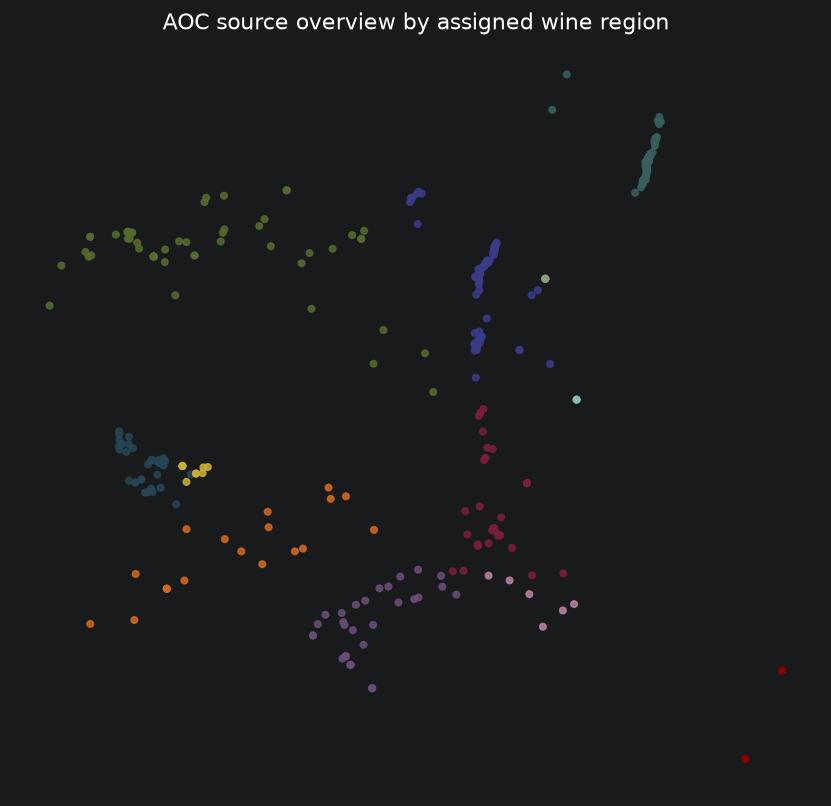

In [4]:
aoc_points = aoc.copy()
aoc_points["geometry"] = aoc_points.geometry.representative_point()

fig, ax = plt.subplots(figsize=(8, 8))
aoc_points.plot(ax=ax, color=aoc_points["colour"], markersize=12, alpha=0.85)
ax.set_title("AOC source overview by assigned wine region")
ax.set_axis_off()
plt.show()


### Optional Raw Polygon Plot

Set `RUN_RAW_POLYGON_PLOT = True` when you want to inspect the full source geometry. This can be noticeably slower than the point overview.

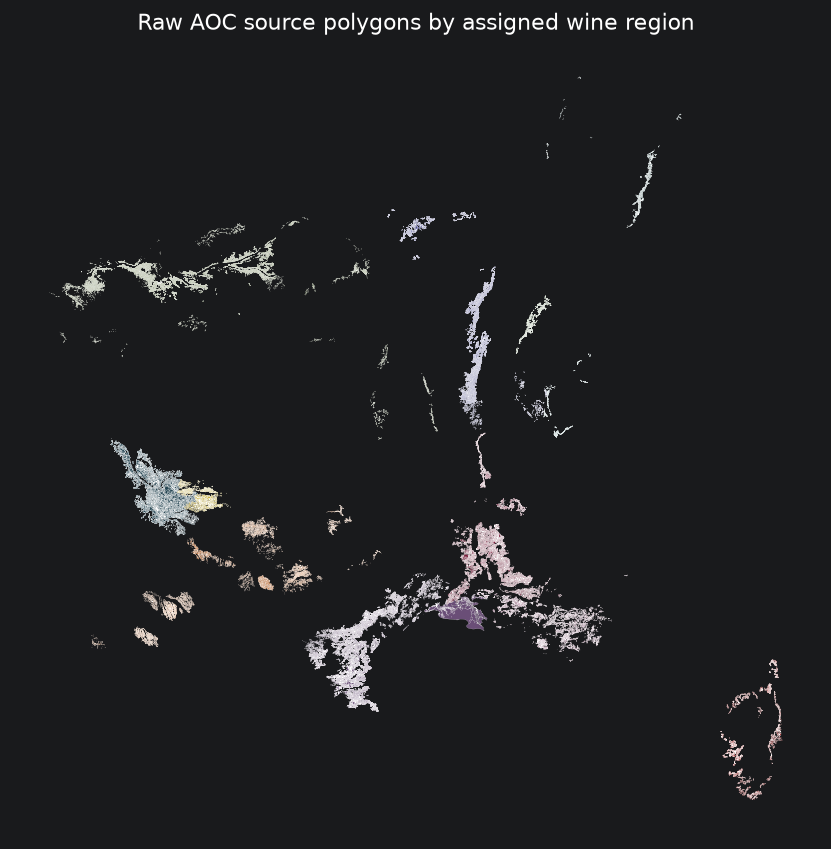

In [5]:
RUN_RAW_POLYGON_PLOT = True

if RUN_RAW_POLYGON_PLOT:
    fig, ax = plt.subplots(figsize=(8, 8))
    aoc.plot(ax=ax, color=aoc["colour"], edgecolor="white", linewidth=0.08)
    ax.set_title("Raw AOC source polygons by assigned wine region")
    ax.set_axis_off()
    plt.show()
else:
    print("Set RUN_RAW_POLYGON_PLOT = True to draw the full source polygons.")


## Payload Strategy Frame

The first app candidate should be boring and measurable: repair topology only where needed, dissolve by `region`, simplify in a metric CRS, reproject to EPSG:4326, then compare payload and visual quality.


In [6]:
strategy_notes = pd.DataFrame([
    {
        "strategy": "Raw AOC polygons",
        "aoc_detail": "yes",
        "payload_expectation": "too high",
        "purpose": "Inspection only; not the first app payload.",
    },
    {
        "strategy": "Dissolve by region",
        "aoc_detail": "no",
        "payload_expectation": "medium",
        "purpose": "First honest baseline for a 12-region map.",
    },
    {
        "strategy": "Repair, dissolve, simplify",
        "aoc_detail": "no",
        "payload_expectation": "low",
        "purpose": "Likely app candidate if visual QA holds up.",
    },
    {
        "strategy": "Simplify AOCs before dissolve",
        "aoc_detail": "partial",
        "payload_expectation": "low-medium",
        "purpose": "Possible, but watch for gaps/slivers.",
    },
    {
        "strategy": "Hull per region",
        "aoc_detail": "no",
        "payload_expectation": "very low",
        "purpose": "Stress test only; likely too crude geographically.",
    },
    {
        "strategy": "Region map plus AOC detail-on-demand",
        "aoc_detail": "yes",
        "payload_expectation": "split",
        "purpose": "Future option if AOC info is useful in the app.",
    },
])

display(strategy_notes)


,strategy,aoc_detail,payload_expectation,purpose
0,Raw AOC polygons,yes,too high,Inspection only; not the first app payload.
1,Dissolve by region,no,medium,First honest baseline for a 12-region map.
2,"Repair, dissolve, simplify",no,low,Likely app candidate if visual QA holds up.
3,Simplify AOCs before dissolve,partial,low-medium,"Possible, but watch for gaps/slivers."
4,Hull per region,no,very low,Stress test only; likely too crude geographica...
5,Region map plus AOC detail-on-demand,yes,split,Future option if AOC info is useful in the app.


## Optional Baseline Experiment

Set `RUN_DISSOLVE_BASELINE = True` when ready. This is intentionally gated because dissolve/repair work is the first place runtime can grow.


Repairing 25 invalid geometries with buffer(0).


,region,aoc_count,colour
0,Alsace,55,#3A5F5F
1,Bordeaux,39,#264653
2,Bourgogne,102,#3B3C88
3,Corse,4,#8B0000
4,Dordogne,9,#C9B037
5,Jura,3,#88A378
6,Languedoc-Roussillon,32,#6A4E77
7,Loire,53,#556B2F
8,Provence,6,#B983A2
9,Rhône,30,#7B1E3C


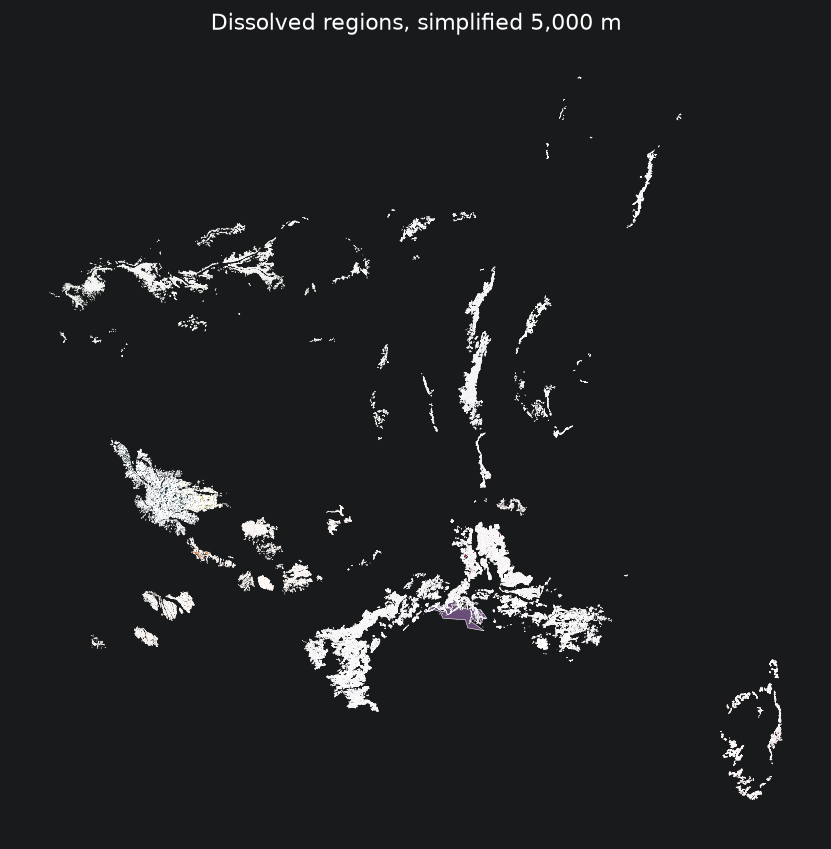

In [7]:
RUN_DISSOLVE_BASELINE = True
METRIC_CRS = "EPSG:2154"
SIMPLIFY_TOLERANCE_METERS = 5_000

if RUN_DISSOLVE_BASELINE:
    working = aoc.to_crs(METRIC_CRS).copy()
    invalid_mask = ~working.geometry.is_valid
    print(f"Repairing {int(invalid_mask.sum())} invalid geometries with buffer(0).")
    working.loc[invalid_mask, "geometry"] = working.loc[invalid_mask, "geometry"].buffer(0)

    dissolved = working.dissolve(
        by="region",
        as_index=False,
        aggfunc={"colour": "first", "app": "count"},
    ).rename(columns={"app": "aoc_count"})

    dissolved["geometry"] = dissolved.geometry.simplify(
        SIMPLIFY_TOLERANCE_METERS,
        preserve_topology=True,
    )
    region_candidate = dissolved.to_crs("EPSG:4326")
    display(region_candidate[["region", "aoc_count", "colour"]])

    fig, ax = plt.subplots(figsize=(8, 8))
    region_candidate.plot(ax=ax, color=region_candidate["colour"], edgecolor="white", linewidth=0.3)
    ax.set_title(f"Dissolved regions, simplified {SIMPLIFY_TOLERANCE_METERS:,} m")
    ax.set_axis_off()
    plt.show()
else:
    print("Set RUN_DISSOLVE_BASELINE = True when ready to run the first heavier geometry experiment.")


## Candidate Output Rule

Do not overwrite source data. When a candidate is ready, write it under `WineData/generated/` with the strategy and tolerance in the filename, then compare file size, coordinate count, and visual quality before touching `assets/data/`.
